<font size="+3">Visualize Real and Synthetic Data</font>

# Imports and Settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError, MeanAbsoluteError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

import matplotlib.pyplot as plt
import seaborn as sns

2026-03-04 21:25:19.878588: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
if gpu_devices:
    print('Using GPU')
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print('Using CPU')

Using CPU


W0000 00:00:1772659534.448878 2554748 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
sns.set_style('white')

In [18]:
path = Path('time_gan')
hdf_store = path / 'TimeSeriesGAN.h5'

In [19]:
seq_len = 252
n_seq = 6

# Load Data

In [21]:
experiment = 0

In [22]:
def get_real_data():
    df = pd.read_hdf(hdf_store, 'data/real').sort_index()

    # Preprocess the dataset:
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df)

    data = []
    for i in range(len(df) - seq_len):
        data.append(scaled_data[i:i + seq_len])
    return data


real_data = get_real_data()

In [23]:
n = len(real_data)

In [24]:
np.asarray(real_data).shape

(3775, 252, 6)

In [25]:
synthetic_data = np.load(path / f'experiment_{experiment:02d}' / 'generated_data.npy')
synthetic_data.shape

(2944, 252, 6)

In [26]:
real_data = real_data[:synthetic_data.shape[0]]

# Prepare Sample

In [27]:
sample_size = 250
idx = np.random.permutation(len(real_data))[:sample_size]

In [28]:
# Data preprocessing
real_sample = np.asarray(real_data)[idx]
synthetic_sample = np.asarray(synthetic_data)[idx]

In [29]:
real_sample_2d = real_sample.reshape(-1, seq_len)
synthetic_sample_2d = synthetic_sample.reshape(-1, seq_len)

In [30]:
real_sample_2d.shape, synthetic_sample_2d.shape

((1500, 252), (1500, 252))

# Visualization in 2D: A Qualitative Assessment of Diversity

## Run PCA

In [16]:
pca = PCA(n_components=2)
pca.fit(real_sample_2d)

pca_real = (pd.DataFrame(pca.transform(real_sample_2d))
            .assign(Data='Real'))
pca_synthetic = (pd.DataFrame(pca.transform(synthetic_sample_2d))
                 .assign(Data='Synthetic'))
pca_result = pd.concat([pca_real, pca_synthetic]).rename(
    columns={0: '1st Component', 1: '2nd Component'})

## Run t-SNE

In [17]:
tsne_data = np.concatenate((real_sample_2d,
                            synthetic_sample_2d), axis=0)

tsne = TSNE(n_components=2,
            verbose=1,
            perplexity=40)
tsne_result = tsne.fit_transform(tsne_data)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.001s...
[t-SNE] Computed neighbors for 3000 samples in 0.220s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 0.127342
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.888287
[t-SNE] KL divergence after 1000 iterations: 0.623412


In [18]:
tsne_result = pd.DataFrame(tsne_result, columns=['X', 'Y']).assign(Data='Real')
tsne_result.loc[sample_size*n_seq:, 'Data'] = 'Synthetic'

## Plot Result

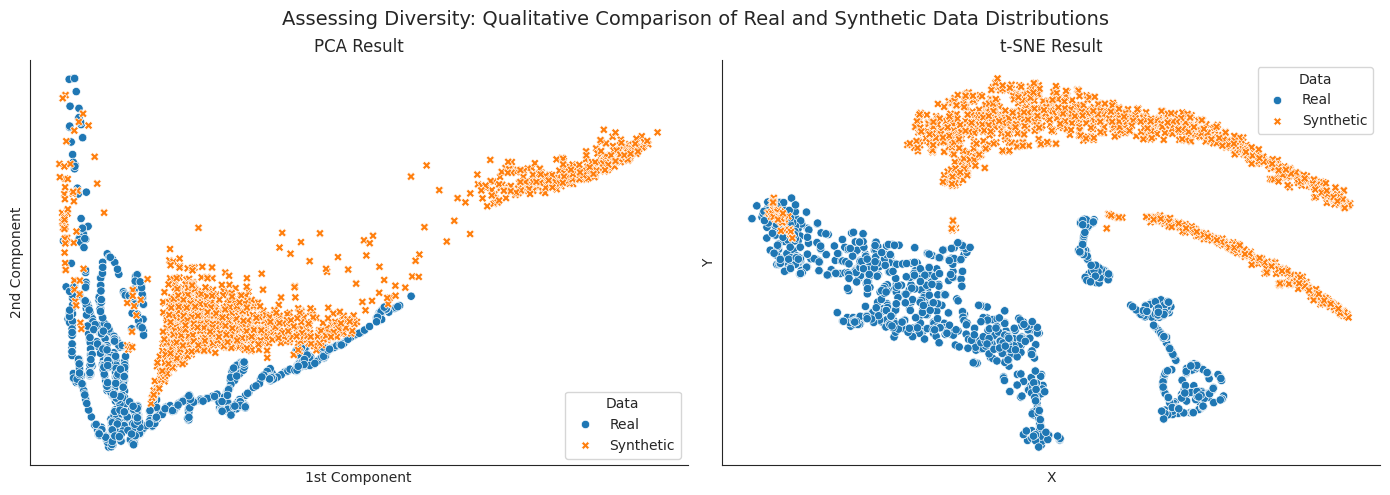

In [19]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 5))

sns.scatterplot(x='1st Component', y='2nd Component', data=pca_result,
                hue='Data', style='Data', ax=axes[0])
sns.despine()
axes[0].set_title('PCA Result')


sns.scatterplot(x='X', y='Y',
                data=tsne_result,
                hue='Data', 
                style='Data', 
                ax=axes[1])
sns.despine()
for i in [0, 1]:
    axes[i].set_xticks([])
    axes[i].set_yticks([])

axes[1].set_title('t-SNE Result')
fig.suptitle('Assessing Diversity: Qualitative Comparison of Real and Synthetic Data Distributions', 
             fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=.88);

# Time Series Classification: A quantitative Assessment of Fidelity

## Prepare Data

In [31]:
real_data = get_real_data()
real_data = np.array(real_data)[:len(synthetic_data)]
real_data.shape

(2944, 252, 6)

In [32]:
synthetic_data.shape

(2944, 252, 6)

In [33]:
n_series = real_data.shape[0]

In [34]:
idx = np.arange(n_series)

In [24]:
n_train = int(.8*n_series)
train_idx = idx[:n_train]
test_idx = idx[n_train:]

In [25]:
train_data = np.vstack((real_data[train_idx], 
                        synthetic_data[train_idx]))
test_data = np.vstack((real_data[test_idx], 
                       synthetic_data[test_idx]))

In [26]:
n_train, n_test = len(train_idx), len(test_idx)
train_labels = np.concatenate((np.ones(n_train),
                               np.zeros(n_train)))
test_labels = np.concatenate((np.ones(n_test),
                              np.zeros(n_test)))

## Create Classifier

In [27]:
ts_classifier = Sequential([Input(shape=(seq_len, n_seq)),
                            GRU(24, name='GRU'),
                            Dense(1, activation='sigmoid', name='OUT')],
                           name='Time_Series_Classifier')

In [28]:
ts_classifier.compile(loss='binary_crossentropy',
                      optimizer='adam',
                      metrics=[AUC(name='AUC'), 'accuracy'])

In [29]:
ts_classifier.summary()

Model: "Time_Series_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ GRU (GRU)                       │ (None, 24)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OUT (Dense)                     │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,329 (9.10 KB)

 Trainable params: 2,329 (9.10 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
result = ts_classifier.fit(x=train_data,
                           y=train_labels,
                           validation_data=(test_data, test_labels),
                           epochs=250,
                           batch_size=128,
                           verbose=0)

KeyboardInterrupt: 

In [ ]:
ts_classifier.evaluate(x=test_data, y=test_labels)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - AUC: 0.8274 - accuracy: 0.8251 - loss: 1.5017


[1.5016707181930542, 0.8273526430130005, 0.825127363204956]

In [ ]:
history = pd.DataFrame(result.history)
history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AUC           250 non-null    float64
 1   accuracy      250 non-null    float64
 2   loss          250 non-null    float64
 3   val_AUC       250 non-null    float64
 4   val_accuracy  250 non-null    float64
 5   val_loss      250 non-null    float64
dtypes: float64(6)
memory usage: 11.8 KB


In [ ]:
from matplotlib.ticker import FuncFormatter

NameError: name 'history' is not defined

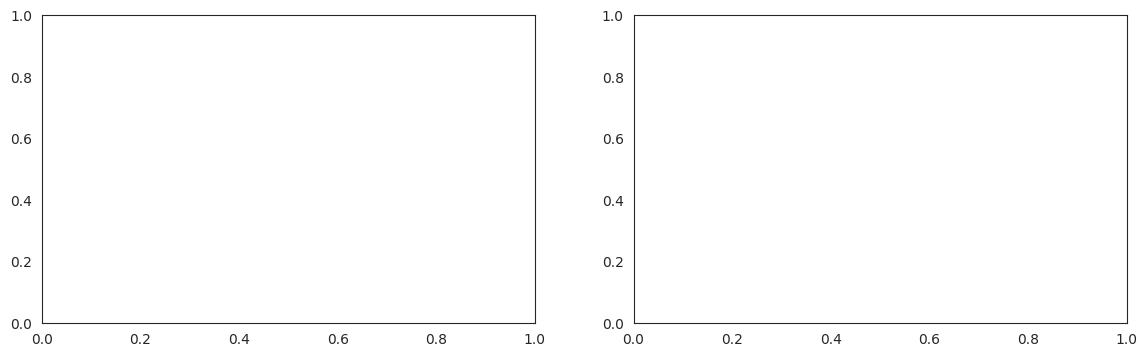

In [ ]:
sns.set_style('white')
fig, axes = plt.subplots(ncols=2, figsize=(14,4))
history[['AUC', 'val_AUC']].rename(columns={'AUC': 'Train', 'val_AUC': 'Test'}).plot(ax=axes[1], 
                                                                                     title='ROC Area under the Curve',
                                                                                    style=['-', '--'],
                                                                                    xlim=(0, 250))
history[['accuracy', 'val_accuracy']].rename(columns={'accuracy': 'Train', 'val_accuracy': 'Test'}).plot(ax=axes[0], 
                                                                                                         title='Accuracy',
                                                                                                        style=['-', '--'],
                                                                                                        xlim=(0, 250))
for i in [0, 1]:
    axes[i].set_xlabel('Epoch')

axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 
axes[0].set_ylabel('Accuracy (%)')
axes[1].set_ylabel('AUC')
sns.despine()
fig.suptitle('Assessing Fidelity: Time Series Classification Performance', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=.85);

# Train on Synthetic, test on real: Assessing usefulness

In [35]:
real_data = get_real_data()
real_data = np.array(real_data)[:len(synthetic_data)]

In [36]:
real_data.shape, synthetic_data.shape

((2944, 252, 6), (2944, 252, 6))

In [33]:
real_train_data = real_data[train_idx, :-1, :]
real_train_label = real_data[train_idx, -1, :]

real_test_data = real_data[test_idx, :-1, :]
real_test_label = real_data[test_idx, -1, :]

In [34]:
real_train_data.shape, real_train_label.shape, real_test_data.shape, real_test_label.shape

((2355, 251, 6), (2355, 6), (589, 251, 6), (589, 6))

In [35]:
synthetic_train = synthetic_data[:, :-1, :]
synthetic_label = synthetic_data[:, -1, :]

In [36]:
synthetic_train.shape, synthetic_label.shape

((2944, 251, 6), (2944, 6))

In [ ]:
def get_model():
    model = Sequential([Input(shape=(seq_len-1, n_seq)),
                        GRU(24),
                        Dense(n_seq)])

    model.compile(optimizer=Adam(),
                  loss=MeanAbsoluteError(name='MAE'))
    return model

In [ ]:
ts_regression = get_model()
synthetic_result = ts_regression.fit(x=synthetic_train,
                                     y=synthetic_label,
                                     validation_data=(
                                         real_test_data, 
                                         real_test_label),
                                     epochs=100,
                                     batch_size=128,
                                     verbose=0)

In [ ]:
ts_regression = get_model()
real_result = ts_regression.fit(x=real_train_data,
                                y=real_train_label,
                                validation_data=(
                                    real_test_data, 
                                    real_test_label),
                                epochs=100,
                                batch_size=128,
                                verbose=0)

In [ ]:
synthetic_result = pd.DataFrame(synthetic_result.history).rename(columns={'loss': 'Train', 'val_loss': 'Test'})
real_result = pd.DataFrame(real_result.history).rename(columns={'loss': 'Train', 'val_loss': 'Test'})

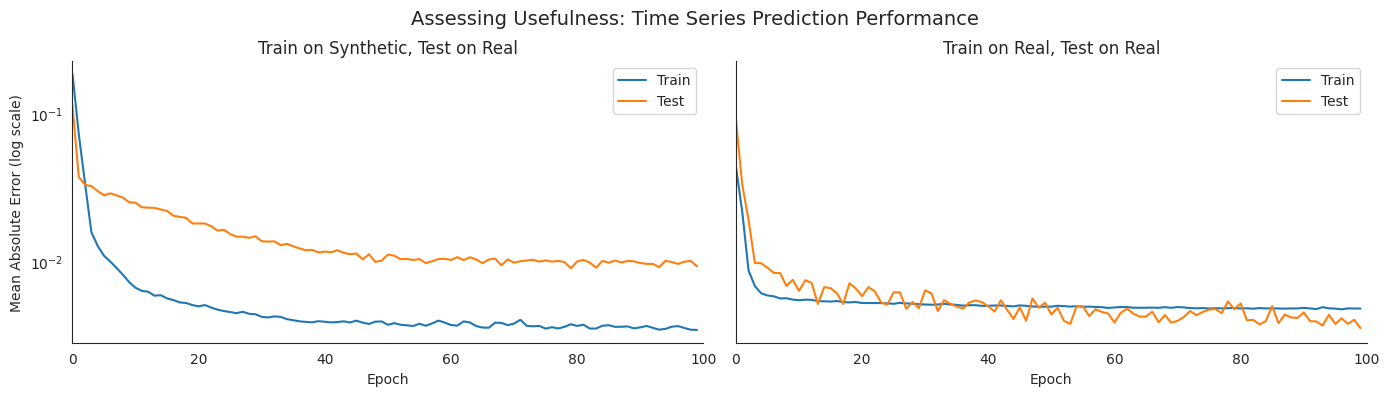

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharey=True)
synthetic_result.plot(ax=axes[0], title='Train on Synthetic, Test on Real', logy=True, xlim=(0, 100))
real_result.plot(ax=axes[1], title='Train on Real, Test on Real', logy=True, xlim=(0, 100))
for i in [0, 1]:
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Mean Absolute Error (log scale)')

sns.despine()
fig.suptitle('Assessing Usefulness: Time Series Prediction Performance', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=.85);

## Additional Evaluation Metrics
Fréchet Distance, DTW, Autocorrelation RMSE, and Discriminative Score

In [38]:
from evaluation_metrics import compute_dtw_distance

# real_data and synthetic_data are already 3D: (n_samples, seq_len, n_seq)
print(f'Real data shape:      {real_data.shape}')
print(f'Synthetic data shape: {synthetic_data.shape}')

# ============================================
# DTW (Dynamic Time Warping) Distance
# ============================================
n_dtw = min(50, len(real_data))
dtw_score = compute_dtw_distance(real_data[:n_dtw], synthetic_data[:n_dtw])
print(f'\nDTW Distance (lower = better, {n_dtw} samples): {dtw_score:.4f}')

# ============================================
# Discriminative Score
# ============================================
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Flatten to 2D for classifier: (n_samples, seq_len * n_seq)
real_2d_flat = real_data.reshape(len(real_data), -1)
synth_2d_flat = synthetic_data.reshape(len(synthetic_data), -1)

X = np.vstack([real_2d_flat, synth_2d_flat])
y = np.concatenate([np.ones(len(real_2d_flat)), np.zeros(len(synth_2d_flat))])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
clf.fit(X_train, y_train)
disc_acc = accuracy_score(y_test, clf.predict(X_test))
disc_score = abs(0.5 - disc_acc)

print(f'\nDiscriminative Score (accuracy closer to 0.5 = better):')
print(f'  Accuracy: {disc_acc:.4f}   Score: {disc_score:.4f}')

# ============================================
# Summary
# ============================================
print('\n' + '=' * 55)
print(f'{"DTW Distance (lower=better)":<45} {dtw_score:>8.4f}')
print(f'{"Discriminative Score (closer to 0=better)":<45} {disc_score:>8.4f}')
print('=' * 55)

Real data shape:      (2944, 252, 6)
Synthetic data shape: (2944, 252, 6)

DTW Distance (lower = better, 50 samples): 122.7850

Discriminative Score (accuracy closer to 0.5 = better):
  Accuracy: 1.0000   Score: 0.5000

DTW Distance (lower=better)                   122.7850
Discriminative Score (closer to 0=better)       0.5000


In [37]:
from evaluation_metrics import evaluate_per_channel

# Run all per-channel metrics at once
# Compares: Open vs Open, High vs High, Close vs Close, etc.
per_ch_results = evaluate_per_channel(real_data, synthetic_data,
                                      num_samples_mmd=100,
                                      max_lag=10,
                                      verbose=True)


PER-CHANNEL EVALUATION SUMMARY  (Real vs Synthetic)
Channel           MMD    W-Dist        KS    ACF-R     ACF-S StdRatio     SkewΔ     KurtΔ
------------------------------------------------------------------------
Open         0.136008 0.131715   0.4956 0.019829 0.016791   2.2031   0.0902   0.4152
High         0.136597 0.132882   0.4956 0.019933 0.016780   2.2321   0.0851   0.4292
Low          0.137924 0.130780   0.5034 0.019882 0.016844   2.1683   0.0999   0.3803
Close        0.137037 0.132364   0.4976 0.019750 0.016609   2.1942   0.0866   0.4195
Volume       0.324703 0.238598   0.7338 0.022311 0.020179   1.5161   0.8966   0.6114
Adj Close    0.042140 0.018399   0.2090 0.109432 0.294872   0.7646   1.4758  13.4193
------------------------------------------------------------------------
MEAN         0.152402 0.130790   0.4892 0.035189 0.063679   1.8464   0.4557   2.6124

Cross-corr Frobenius dist (norm): 0.094753


In [ ]:
# ---- Per-Channel Autocorrelation Plots ----
from evaluation_metrics import CHANNEL_NAMES_OHLCV

def _acf_vectors(data, max_lag=10):
    """Return per-channel ACF arrays for plotting."""
    data = np.asarray(data)
    n_ch = data.shape[2]
    out = {}
    for ch in range(n_ch):
        flat = data[:, :, ch].flatten()
        mean, var = np.mean(flat), np.var(flat)
        acf = np.array([
            np.mean((flat[:-lag] - mean) * (flat[lag:] - mean)) / (var + 1e-8)
            for lag in range(1, max_lag + 1)
        ])
        name = CHANNEL_NAMES_OHLCV[ch] if ch < len(CHANNEL_NAMES_OHLCV) else f'Ch{ch}'
        out[name] = acf
    return out

real_acfs = _acf_vectors(real_data)
synth_acfs = _acf_vectors(synthetic_data)
real_sq_acfs = _acf_vectors(real_data ** 2)
synth_sq_acfs = _acf_vectors(synthetic_data ** 2)

channels = list(real_acfs.keys())
n_ch = len(channels)
lags = np.arange(1, 11)
w = 0.3

fig, axes = plt.subplots(n_ch, 2, figsize=(14, 3 * n_ch), sharex=True)

for i, name in enumerate(channels):
    axes[i, 0].bar(lags - w/2, real_acfs[name], width=w, label='Real', alpha=0.8)
    axes[i, 0].bar(lags + w/2, synth_acfs[name], width=w, label='Synthetic', alpha=0.8)
    axes[i, 0].set_ylabel(name)
    axes[i, 0].legend(fontsize=8)
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].bar(lags - w/2, real_sq_acfs[name], width=w, label='Real', alpha=0.8)
    axes[i, 1].bar(lags + w/2, synth_sq_acfs[name], width=w, label='Synthetic', alpha=0.8)
    axes[i, 1].set_ylabel(name)
    axes[i, 1].legend(fontsize=8)
    axes[i, 1].grid(True, alpha=0.3)

axes[0, 0].set_title('ACF of Returns')
axes[0, 1].set_title('ACF of Squared Returns (Volatility Clustering)')
axes[-1, 0].set_xlabel('Lag')
axes[-1, 1].set_xlabel('Lag')

sns.despine()
fig.suptitle('Per-Channel Autocorrelation: Real vs Synthetic', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=.95)
plt.show()